In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file = pd.read_csv("./YearPredictionMSD.txt", header=None, delimiter=',')

In [3]:
train_df = file.iloc[:463715]
test_df  = file.iloc[463715:]

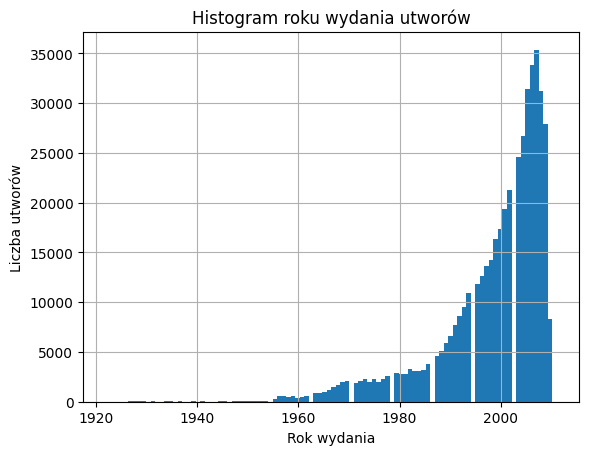

In [4]:
train_df[0].hist(bins=100)
plt.title('Histogram roku wydania utworów')
plt.xlabel('Rok wydania')
plt.ylabel('Liczba utworów')
plt.show()

In [5]:
y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values

A_train = np.c_[np.ones(X_train.shape[0]), X_train]
A_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [ ]:
f_min = X_train.min(axis=0)
f_max = X_train.max(axis=0)

denominator_f = np.where((f_max - f_min) == 0, 1, (f_max - f_min))

In [9]:
X_train_scaled = (X_train - f_min) / denominator_f
X_test_scaled = (X_test - f_min) / denominator_f

A_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
A_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

In [10]:

y_min = y_train.min()
y_max = y_train.max()

denominator_y = 1 if (y_max - y_min) == 0 else (y_max - y_min)

y_train_scaled = (y_train - y_min) / denominator_y
y_test_scaled = (y_test - y_min) / denominator_y

# e

In [11]:
def fit_ols(A, y): # ordinary least squares
    M = A.T @ A
    
    v = A.T @ y
    
    w = np.linalg.solve(M, v)
    return w

In [12]:

w_unscaled = fit_ols(A_train, y_train)

w_scaled = fit_ols(A_train_scaled, y_train_scaled)

In [13]:
print(f"Wymiary wektora wag (surowe): {w_unscaled.shape}")
print(f"Wymiary wektora wag (znormalizowane): {w_scaled.shape}")

Wymiary wektora wag (surowe): (91,)
Wymiary wektora wag (znormalizowane): (91,)
